#### Name: Sutton Ursillo

# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [2]:
# import statements here
import math
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [ ]:
def v(t,b,m,v0):
    g = 9.81 #m/s^2 #defining a constant
    return v0*np.exp(-b/m * t) + (m*g/b)*(1-np.exp(-b/m*t)) #returning the solved diff eqn


#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [ ]:
time = np.arange(0,101,2) #making an array of time points that go by 2 seconds
#constants
m = 1.0 #kg
b = 0.1 #N/(m/s)
v0 = 0 #m/s

#calling the functing we defined with the constants and printing the results
velos = v(time,b,m,v0)
print(velos)

[ 0.         17.78251312 32.34160348 44.2615785  54.02082862 62.01102682
 68.55284781 73.90883784 78.29395158 81.88417907 84.82360871 87.23021016
 89.20056878 90.81376198 92.13453286 93.21588859 94.10122779 94.82608222
 95.41954283 95.90542728 96.30323583 96.62893391 96.89559296 97.11391491
 97.29266181 97.4390074  97.55882503 97.65692341 97.73723957 97.80299688
 97.85683441 97.90091285 97.93700123 97.9665479  97.99073866 98.01054438
 98.02675993 98.0400361  98.05090571 98.059805   98.06709112 98.07305648
 98.07794052 98.08193922 98.08521309 98.0878935  98.09008803 98.09188477
 98.09335581 98.0945602  98.09554627]


#### Step 3: 
Make a plot of the results. 

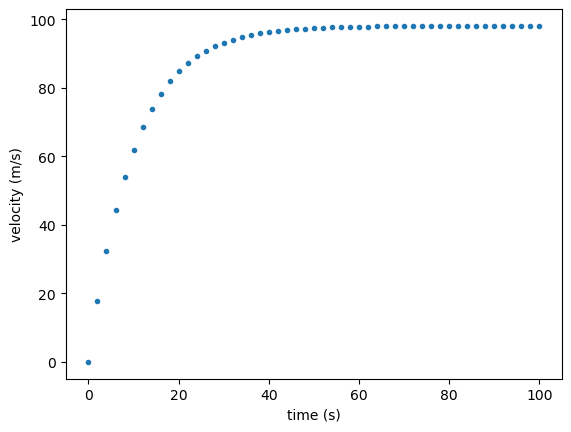

In [ ]:
#printing the graph we made 
plt.plot(time,velos,".")
plt.xlabel("time (s)")
plt.ylabel("velocity (m/s)")
plt.show()

I was able to call the function that was defined and create a grpah of the velocities. This grpah shows how over time the object approaches its terminal velocity and that the increase in velocity between each point gets smaller and smaller.

### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [26]:
#function for the vertical portion
def f(v):
    g = 9.81 #m/s
    return g - (b/m)*v

#Eulers method
def euler(t,h,v0,f):
    v = np.zeros(len(t)) #the same length as the time points
    v[0] = v0 #initial velo at  0 m/s^2
    for i in range(len(t)-1): #for the values in the time array
        v[i+1] = v[i] + h*f(v[i]) #we can apply eulers method 

    return v


h = 2 #step size




#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

[ 0.         19.62       35.316      47.8728     57.91824    65.954592
 72.3836736  77.52693888 81.6415511  84.93324088 87.56659271 89.67327417
 91.35861933 92.70689547 93.78551637 94.6484131  95.33873048 95.89098438
 96.33278751 96.68623    96.968984   97.1951872  97.37614976 97.52091981
 97.63673585 97.72938868 97.80351094 97.86280875 97.910247   97.9481976
 97.97855808 98.00284647 98.02227717 98.03782174 98.05025739 98.06020591
 98.06816473 98.07453178 98.07962543 98.08370034 98.08696027 98.08956822
 98.09165457 98.09332366 98.09465893 98.09572714 98.09658171 98.09726537
 98.0978123  98.09824984 98.09859987]


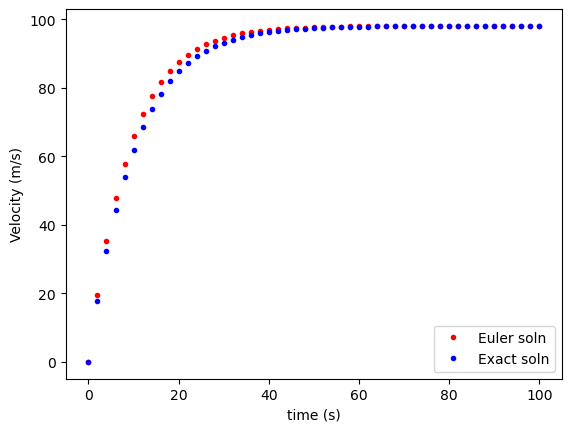

In [ ]:
#calling the function and prinitng it
v_euler = euler(time,h,v0,f)
print(v_euler)

#plotting the exact and Euler soln on the same graph.
#making a legend and having them in different colors so we can see the difference. 
plt.plot(time,v_euler, ".", color = "red", label= "Euler soln")
plt.plot(time,velos, ".", color= "blue", label = "Exact soln")
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()

I was able to calculate the velocity over a period of time while using Eulers method. Then plotting the exact soln with Euler soln on a graph to compare the results. They are similar but the difference in there calues can easily be seen in the graph. 

### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

[ 0.         17.78226    32.341189   44.26106948 54.02027295 62.01045814
 68.55228909 73.90830416 78.29345222 81.88371912 84.8231903  87.22983334
 89.20023221 90.81346346 92.13426965 93.2156577  94.10102615 94.82590681
 95.41939077 95.90529587 96.30312257 96.62883655 96.89550945 97.11384343
 97.29260075 97.43895532 97.55878068 97.65688571 97.73720756 97.80296973
 97.85681142 97.9008934  97.93698479 97.96653402 97.99072695 98.01053451
 98.02675162 98.04002911 98.05089983 98.05980006 98.06708697 98.073053
 98.0779376  98.08193677 98.08521103 98.08789178 98.0900866  98.09188357
 98.09335481 98.09455936 98.09554557]


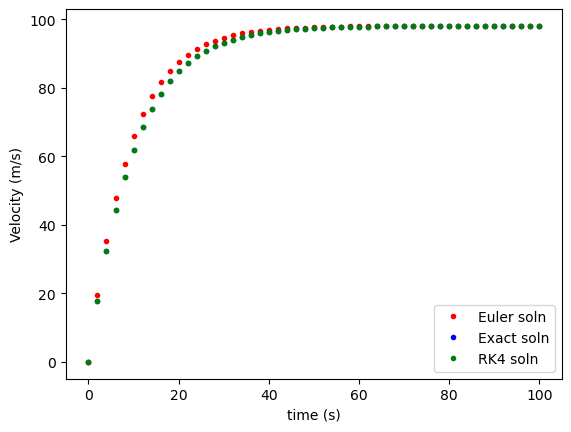

In [ ]:
#function for RK4 method
def RK4(t,h,v0,f):
    v = np.zeros(len(t)) #same set up as euler
    v[0] = v0
    #applying thr 4th order RK method
    for i in range(len(t)-1):
        k1 = h*f(v[i]) # have to be careful here as f() only takes one argument. (I had some problems with that at the start)
        k2 = h*f(v[i]+0.5*k1)
        k3 = h*f(v[i]+0.5*k2)
        k4 = h*f(v[i]+k3)
        v[i+1] = v[i] + (k1 + 2*k2 + 2*k3 + k4)/6 
    return v

v_RK4 = RK4(time,h,v0,f)
print(v_RK4)

#plotting all of the solns onto one plot
plt.plot(time,v_euler, ".", color = "red", label= "Euler soln")
plt.plot(time,velos, ".", color= "blue", label = "Exact soln")
plt.plot(time, v_RK4, ".", color = "green", label= "RK4 soln" )
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()


### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

After plotting all of the solns onto one graph I can see that RK4 and exact soln match and there is not much difference between them. The Euler soln is off compared to the other two. RK4 takes in more slope values at each step so the overall result is much more accurate compared to Euler. 

### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

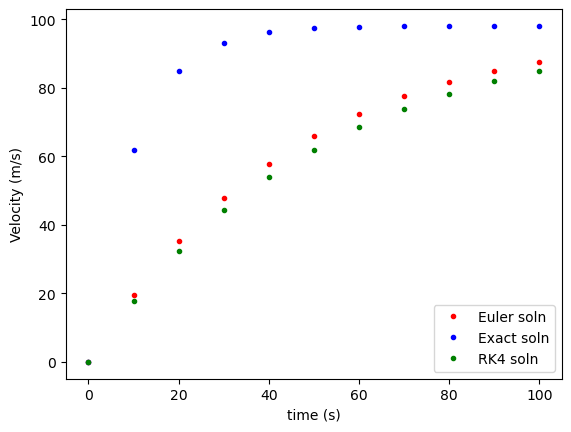

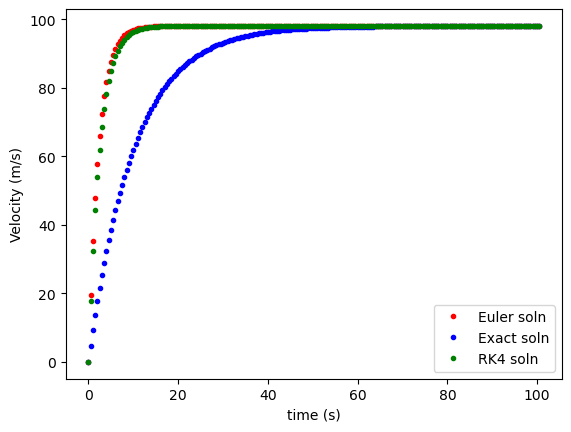

In [ ]:
#bigger time steps

time = np.arange(0,101,10)
v_RK4 = RK4(time,h,v0,f)
v_euler = euler(time,h,v0,f)
velos = v(time,b,m,v0)

plt.plot(time,v_euler, ".", color = "red", label= "Euler soln")
plt.plot(time,velos, ".", color= "blue", label = "Exact soln")
plt.plot(time, v_RK4, ".", color = "green", label= "RK4 soln" )
plt.legend()
plt.xlabel("time (s) ")
plt.ylabel("Velocity (m/s)")
plt.show()

#smaller time steps

time = np.arange(0,101,0.5)
v_RK4 = RK4(time,h,v0,f)
v_euler = euler(time,h,v0,f)
velos = v(time,b,m,v0)

plt.plot(time,v_euler, ".", color = "red", label= "Euler soln")
plt.plot(time,velos, ".", color= "blue", label = "Exact soln")
plt.plot(time, v_RK4, ".", color = "green", label= "RK4 soln" )
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("Velocity (m/s)")
plt.show()


#### Explanation Markdown Cell: 

The top graph shows the methods when the time steps are larger and the bottom graph shows when the time steps are smaller. Euler and RK4 methods are not accurate when they do not have lots of points or data. There final result is way off compared to the exact soln so, it is important that they have enough data to work with. When the step size is very small and there are a lot of data points the methods all end up in the same place but how they got there is different. The RK4 and Euler take a similar path but it is off from the exact solution. 